# Requirements
pandas numpy matplotlib seaborn scikit-learn

In [65]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [66]:
df = pd.read_csv("OnlineRetail.csv", encoding='latin1')

In [67]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [69]:
print(df.shape)
print(df.columns)

(541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


# Data Cleaning

In [70]:
#Check Missing Values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# RFM Analysis: Recency Frequency Monetary

In [71]:
#Remove Missing Customer IDs
##Customer segmentation requires customer identification.
df = df.dropna(subset=['CustomerID'])

In [72]:
#Remove Returns/Cancellations
##Invoices starting with "C" are returns.
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [73]:
#Remove Negative Quantities
df = df[df['Quantity'] > 0]

In [74]:
#Create Total Amount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [75]:
#Convert Date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#Create Reference Date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

#Calculate RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# Scale Features
## K-Means needs scaled data.

In [76]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

# Find Best Number of Clusters

## Elbow Method

In [77]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

## Plot Elbow Curve

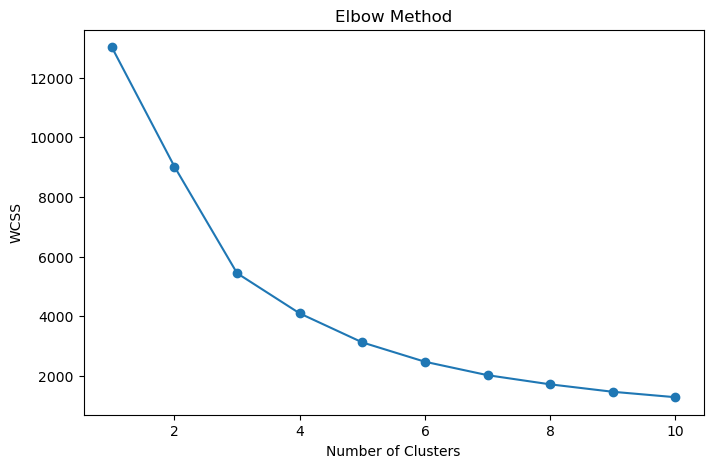

In [78]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

# Apply K-Means

In [79]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [80]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,1


# Analyze Segments

In [81]:
segment_summary = rfm.groupby('Cluster').mean()

print(segment_summary)

            Recency  Frequency       Monetary
Cluster                                      
0         15.672986  22.047393   12453.225924
1        248.564030   1.551789     478.107581
2          7.384615  82.692308  127338.313846
3         43.910580   3.655748    1349.698298


# Name the Segments

In [82]:
segment_names = {
    0: "VIP Customers",
    1: "Lost Customers",
    2: "Champions",
    3: "Loyal Customers"
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
Champions,7.384615,82.692308,127338.313846
Lost Customers,248.564030,1.551789,478.107581
Loyal Customers,43.910580,3.655748,1349.698298
VIP Customers,15.672986,22.047393,12453.225924


# Visualization

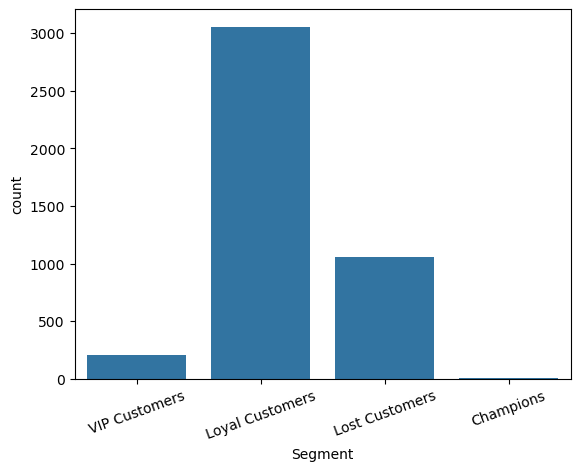

In [83]:
#Customer Count per Segment
sns.countplot(
    x='Segment',
    data=rfm
)

plt.xticks(rotation=20)
plt.show()

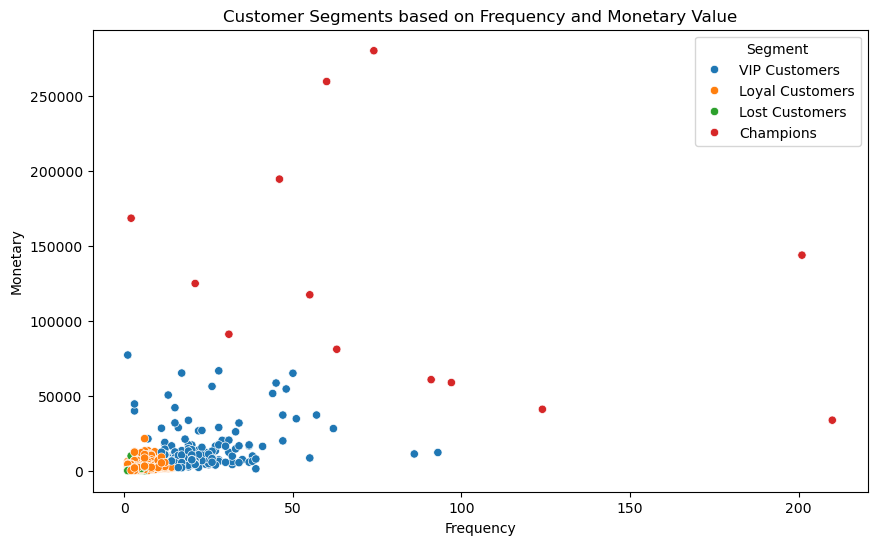

In [84]:
#Scatter Plot
plt.figure(figsize=(10,6))
plt.title("Customer Segments based on Frequency and Monetary Value")

sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='Segment',
    data=rfm
)

plt.show()

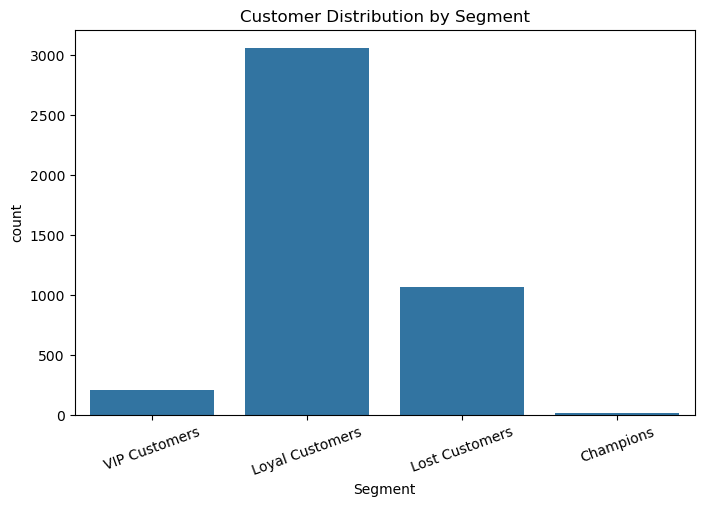

In [85]:
#Segment Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    x='Segment',
    data=rfm
)

plt.title('Customer Distribution by Segment')
plt.xticks(rotation=20)

plt.show()

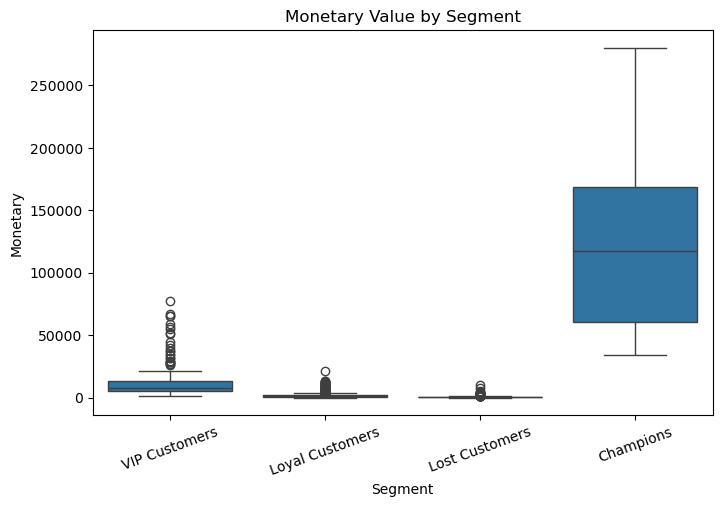

In [86]:
#Monetary Value by Segment
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Segment',
    y='Monetary',
    data=rfm
)

plt.xticks(rotation=20)
plt.title('Monetary Value by Segment')

plt.show()

# Business Insights
1. Champions are the most valuable customer segment. They have the highest purchase frequency, highest spending, and the most recent transactions. These customers should be rewarded through exclusive offers, loyalty programs, and personalized experiences to maintain their engagement.
2. VIP Customers contribute significantly to overall revenue and make frequent purchases. Businesses can increase their value through premium memberships, targeted promotions, and product recommendations.
3. Loyal Customers purchase regularly but spend less compared to Champions and VIP Customers. Cross-selling and upselling strategies can encourage higher spending and strengthen customer relationships.
4. Lost Customers show low purchase frequency, low spending, and long periods of inactivity. Re-engagement campaigns, discounts, and personalized communication can help recover some of these customers.
5. Customer segmentation enables businesses to understand customer behavior more effectively, optimize marketing efforts, improve customer retention, and maximize revenue generation.

# Conclusion
This project successfully performed customer segmentation using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering on the Online Retail dataset. After cleaning and preprocessing the data, customer purchasing behavior was analyzed and grouped into distinct segments based on their transaction patterns.

The clustering process identified four key customer groups: Champions, VIP Customers, Loyal Customers, and Lost Customers. Each segment exhibited unique characteristics in terms of recency, purchase frequency, and monetary value. These insights can help businesses design targeted marketing strategies, improve customer retention, and allocate resources more effectively.

Overall, customer segmentation provides valuable business intelligence by transforming raw transaction data into actionable insights, enabling organizations to make data-driven decisions and enhance customer relationship management.